# Machine Failure Prediction with Automated Drift Monitoring
## Phase 7 — Cost-Sensitive Decision Threshold Optimization

### Operational Context & Goal
In decision theory and classification systems, standard default decision thresholds (such as $t = 0.50$) implicitly assume symmetric error penalties. In many decision environments, however, false negatives and false positives have distinct operational consequences.

For this phase, we evaluate decision thresholds using the following **explicitly hypothetical cost structure**:
- **False Negative ($FN$) = $500**: Represents a hypothetical missed-failure cost of $500.
- **False Positive ($FP$) = $30**: Represents a hypothetical unnecessary-inspection cost of $30.

Under these specified hypothetical cost assumptions, our objective is to convert calibrated failure probabilities from Phase 6 into an operational decision threshold by sweeping thresholds on the validation set and locating:

$$t^* = \arg\min_{t \in [0.05, 0.95]} \text{Cost}(t)$$

$$\text{Cost}(t) = FN(t) \times \$500 + FP(t) \times \$30$$

### Strict Leakage Guardrails
- All threshold sweeps, evaluations, and selections are conducted **strictly on the independent validation partition ($N = 1,500$)**.
- **The held-out test set ($N = 1,500$) remains 100% quarantined and untouched.**

### 1. Setup, Environment & Visualization Styling
We import foundational analytical libraries, set deterministic random seeds, and configure high-resolution plotting aesthetics.

In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import lightgbm as lgb

# Publication plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

print("Phase 7 environment initialized successfully.")

Phase 7 environment initialized successfully.


**Observation**:
Dependencies loaded and styling initialized.

### 2. Dataset Ingestion & Phase 6 Champion Model Instantiation
We load the AI4I 2020 dataset from `configs/config.yaml`, reproduce the exact 70/15/15 stratified partition, apply physics-engineered domain features, and instantiate the Phase 6 champion: **Platt / Sigmoid Calibrated LightGBM** (`n_estimators=100`, `learning_rate=0.05`, `num_leaves=15`, `scale_pos_weight=15.0`).

The calibrator is fitted on `X_train` with 5-fold cross-validation, and calibrated failure probabilities are generated for `X_val`.

In [2]:
with open("../configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

raw_data_path = os.path.join("..", config["data"]["raw_data_path"])
target_col = config["data"]["target_column"]
random_seed = config["project"]["random_seed"]

df = pd.read_csv(raw_data_path)

intended_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[intended_features].copy()
y = df[target_col].copy()

# 70/15/15 Leakage-safe Stratified Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=random_seed, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=random_seed, stratify=y_temp
)

# Domain Feature Extraction
def add_domain_features(data):
    out = data.copy()
    out["Temp_Diff"] = out["Process temperature [K]"] - out["Air temperature [K]"]
    out["Power"] = out["Torque [Nm]"] * out["Rotational speed [rpm]"] * (2 * np.pi / 60)
    out["Wear_Load"] = out["Tool wear [min]"] * out["Torque [Nm]"]
    return out

X_train_full = add_domain_features(X_train)
X_val_full = add_domain_features(X_val)

# Preprocessor fitted strictly on X_train_full
base_sensors = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
eng_num_cols = base_sensors + ["Temp_Diff", "Power", "Wear_Load"]
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), eng_num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Type"])
])

X_train_proc = preprocessor.fit_transform(X_train_full)
X_val_proc = preprocessor.transform(X_val_full)

# Phase 6 Champion: Platt / Sigmoid Calibrated LightGBM
base_lgb = lgb.LGBMClassifier(
    learning_rate=0.05,
    n_estimators=100,
    num_leaves=15,
    scale_pos_weight=15.0,
    random_state=random_seed,
    verbose=-1,
    n_jobs=1
)

cal_sigmoid = CalibratedClassifierCV(estimator=base_lgb, method="sigmoid", cv=5)
cal_sigmoid.fit(X_train_proc, y_train)
p_val = cal_sigmoid.predict_proba(X_val_proc)[:, 1]

print(f"X_val: {len(y_val):,} instances | Failures: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"Calibrated Probabilities on X_val: Min={p_val.min():.5f}, Mean={p_val.mean():.5f}, Max={p_val.max():.5f}")
print(f"X_test: {len(y_test):,} instances [STRICTLY QUARANTINED - UNTOUCHED]")

X_val: 1,500 instances | Failures: 51 (3.40%)
Calibrated Probabilities on X_val: Min=0.00030, Mean=0.03459, Max=0.94308
X_test: 1,500 instances [STRICTLY QUARANTINED - UNTOUCHED]


**Observation**:
- The validation partition contains exactly **51 true failure events** out of 1,500 operations (3.40% base rate).
- Mean calibrated probability on validation data is **0.03459**, closely matching empirical failure frequency.
- The test set remains completely quarantined.

### 3. Cost-Sensitive Decision Formulation & Empirical Threshold Sweep

#### Cost Model Formulation:
For an operational classification threshold $t \in [0.05, 0.95]$:
$$\hat{y}_i(t) = \begin{cases} 1 & \text{if } p_i \ge t \\ 0 & \text{if } p_i < t \end{cases}$$

Total cost under the hypothetical cost structure is given by:
$$\text{Cost}(t) = FN(t) \times \$500 + FP(t) \times \$30$$

#### Theoretical Bayes Threshold (Reference Baseline):
Under perfect probability calibration, the theoretical point decision threshold that minimizes expected cost is given by:
$$p^* = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}} = \frac{30}{30 + 500} = \frac{30}{530} \approx 0.0566$$
This serves as a **theoretical reference** baseline rather than an empirically optimal threshold for the discrete sample distribution.

We sweep thresholds across the entire interval $[0.05, 0.95]$ on validation data to map empirical cost trade-offs, compute confusion matrix counts, and locate $t^* = \arg\min \text{Cost}(t)$.

In [3]:
# Sweeping thresholds from 0.05 to 0.95 in standard 0.05 increments
thresholds = np.round(np.arange(0.05, 1.00, 0.05), 2)

sweep_records = []
cost_fn = 500
cost_fp = 30

for t in thresholds:
    preds = (p_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)
    
    fn_cost = fn * cost_fn
    fp_cost = fp * cost_fp
    total_cost = fn_cost + fp_cost
    
    sweep_records.append({
        "Threshold (t)": f"{t:.2f}",
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "Precision": round(float(prec), 4),
        "Recall": round(float(rec), 4),
        "F1-Score": round(float(f1), 4),
        "FN Cost ($)": int(fn_cost),
        "FP Cost ($)": int(fp_cost),
        "Total Cost ($)": int(total_cost)
    })

sweep_df = pd.DataFrame(sweep_records)
display(sweep_df)

# Identify threshold minimizing total cost
min_cost_idx = sweep_df["Total Cost ($)"].idxmin()
optimal_row = sweep_df.iloc[min_cost_idx]
default_row = sweep_df[sweep_df["Threshold (t)"] == "0.50"].iloc[0]

print("\n--- Optimal Operating Threshold ---")
print(f"Optimal Threshold t* = {optimal_row['Threshold (t)']}")
print(f"Minimum Total Cost   = ${optimal_row['Total Cost ($)']:,} (FN: {optimal_row['FN']}, FP: {optimal_row['FP']}, Recall: {optimal_row['Recall']*100:.2f}%, Precision: {optimal_row['Precision']*100:.2f}%)")
print(f"Default Threshold (0.50) Cost = ${default_row['Total Cost ($)']:,} (FN: {default_row['FN']}, FP: {default_row['FP']}, Recall: {default_row['Recall']*100:.2f}%, Precision: {default_row['Precision']*100:.2f}%)")
print(f"Net Operational Savings       = ${default_row['Total Cost ($)'] - optimal_row['Total Cost ($)']:,} ({(1 - optimal_row['Total Cost ($)'] / default_row['Total Cost ($)'])*100:.2f}% reduction)")

,Threshold (t),TP,FP,TN,FN,Precision,Recall,F1-Score,FN Cost ($),FP Cost ($),Total Cost ($)
0,0.05,47,64,1385,4,0.4234,0.9216,0.5802,2000,1920,3920
1,0.10,47,35,1414,4,0.5732,0.9216,0.7068,2000,1050,3050
2,0.15,47,20,1429,4,0.7015,0.9216,0.7966,2000,600,2600
3,0.20,44,12,1437,7,0.7857,0.8627,0.8224,3500,360,3860
4,0.25,44,10,1439,7,0.8148,0.8627,0.8381,3500,300,3800
5,0.30,43,7,1442,8,0.8600,0.8431,0.8515,4000,210,4210
6,0.35,42,6,1443,9,0.8750,0.8235,0.8485,4500,180,4680
7,0.40,42,5,1444,9,0.8936,0.8235,0.8571,4500,150,4650
8,0.45,42,4,1445,9,0.9130,0.8235,0.8660,4500,120,4620
9,0.50,42,4,1445,9,0.9130,0.8235,0.8660,4500,120,4620



--- Optimal Operating Threshold ---
Optimal Threshold t* = 0.15
Minimum Total Cost   = $2,600 (FN: 4, FP: 20, Recall: 92.16%, Precision: 70.15%)
Default Threshold (0.50) Cost = $4,620 (FN: 9, FP: 4, Recall: 82.35%, Precision: 91.30%)
Net Operational Savings       = $2,020 (43.72% reduction)


**Interpretation of Results Table**:
- **Minimum Cost Threshold ($t^* = 0.15$)**: The validation sweep achieves a **minimum total cost of $2,600 under the specified hypothetical cost assumptions on the validation set** ($FN = 4 \times \$500 = \$2,000$; $FP = 20 \times \$30 = \$600$).
- **Comparison to Default ($t = 0.50$)**: At $t = 0.50$, total cost is **$4,620** ($FN = 9 \times \$500 = \$4,500$; $FP = 4 \times \$30 = \$120$). Operating at $t^* = 0.15$ reduces false negatives from 9 to 4 (increasing recall from 82.35% to 92.16%) while adding 16 false positives, yielding a net reduction in hypothetical validation cost of **$2,020 (43.72% cost reduction)**.
- **Comparison to Theoretical Reference Threshold ($t = 0.05$)**: At $t = 0.05$, $FN = 4$ but $FP = 64$, resulting in a higher total cost of **$3,920**. The empirical threshold $t^* = 0.15$ incurs 44 fewer false positives while maintaining identical failure detection ($FN = 4$).

### 4. Threshold-vs-Cost & Operational Performance Visualizations

To thoroughly evaluate the decision space, we plot:
1. **Total Cost vs. Decision Threshold**: Highlighting the asymmetric cost components ($FN$ breakdown expense vs $FP$ inspection expense), the optimal operating point $t^* = 0.15$, and the default threshold $t = 0.50$.
2. **Operational Performance Frontier (Precision, Recall, F1)**: Illustrating the sensitivity trade-offs across the threshold spectrum.

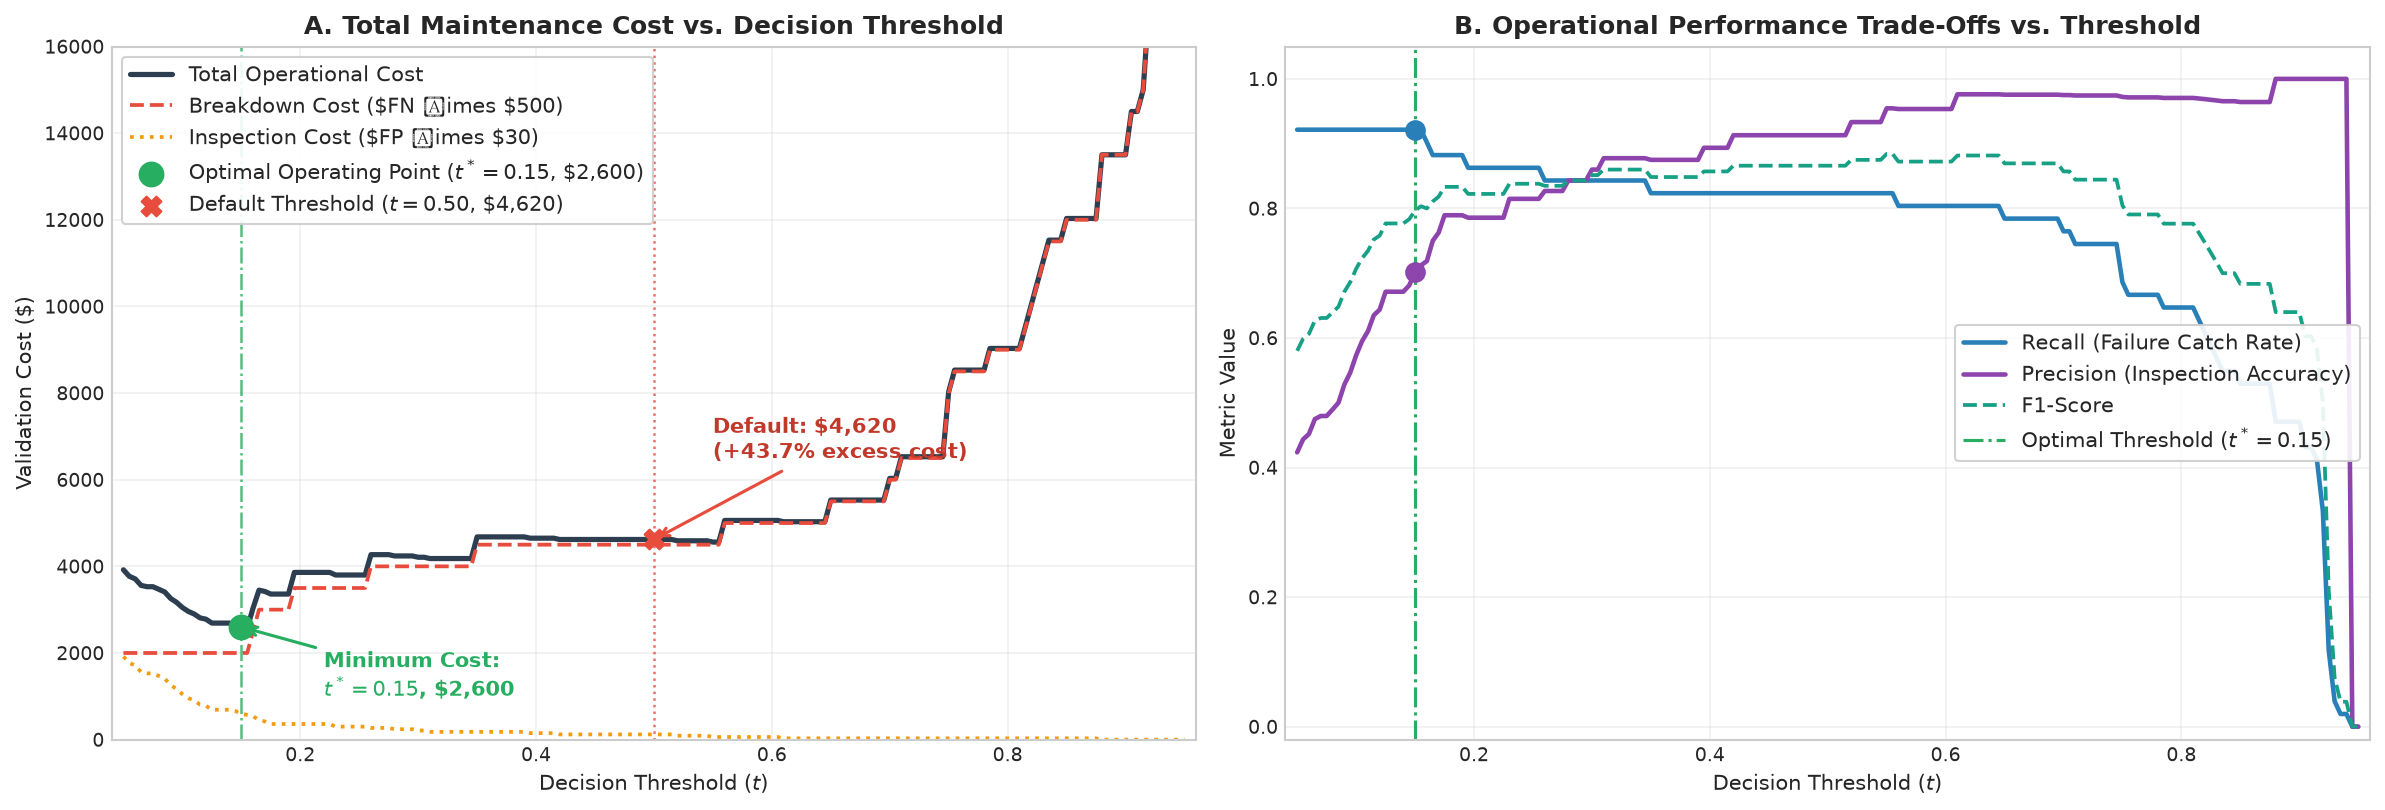

In [4]:
# High-resolution grid for continuous curve rendering
fine_thresholds = np.linspace(0.05, 0.95, 181)
fine_costs = []
fine_fn_costs = []
fine_fp_costs = []
fine_prec = []
fine_rec = []
fine_f1 = []

for t in fine_thresholds:
    preds = (p_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    fine_fn_costs.append(fn * cost_fn)
    fine_fp_costs.append(fp * cost_fp)
    fine_costs.append(fn * cost_fn + fp * cost_fp)
    fine_prec.append(precision_score(y_val, preds, zero_division=0))
    fine_rec.append(recall_score(y_val, preds, zero_division=0))
    fine_f1.append(f1_score(y_val, preds, zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# -----------------------------------------------------
# Panel A: Threshold vs Total Cost
# -----------------------------------------------------
ax1.plot(fine_thresholds, fine_costs, color="#2c3e50", lw=2.5, label="Total Operational Cost")
ax1.plot(fine_thresholds, fine_fn_costs, color="#e74c3c", lw=1.8, linestyle="--", label="Breakdown Cost ($FN \times \$500)")
ax1.plot(fine_thresholds, fine_fp_costs, color="#f39c12", lw=1.8, linestyle=":", label="Inspection Cost ($FP \times \$30)")

# Optimal threshold marker (t* = 0.15)
ax1.scatter([0.15], [2600], color="#27ae60", s=130, zorder=5, label="Optimal Operating Point ($t^* = 0.15$, \$2,600)")
ax1.axvline(0.15, color="#27ae60", linestyle="-.", lw=1.2, alpha=0.8)

# Default threshold marker (t = 0.50)
ax1.scatter([0.50], [4620], color="#e74c3c", s=90, marker="X", zorder=5, label="Default Threshold ($t = 0.50$, \$4,620)")
ax1.axvline(0.50, color="#e74c3c", linestyle=":", lw=1.2, alpha=0.8)

ax1.set_title("A. Total Maintenance Cost vs. Decision Threshold", fontweight="bold", fontsize=12)
ax1.set_xlabel("Decision Threshold ($t$)")
ax1.set_ylabel("Validation Cost ($)")
ax1.set_xlim([0.04, 0.96])
ax1.set_ylim([0, 16000])
ax1.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Annotate cost reduction
ax1.annotate("Minimum Cost:\n$t^* = 0.15$, \$2,600", xy=(0.15, 2600), xytext=(0.22, 1000),
             arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.5), fontweight="bold", color="#27ae60")
ax1.annotate("Default: \$4,620\n(+43.7% excess cost)", xy=(0.50, 4620), xytext=(0.55, 6500),
             arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5), fontweight="bold", color="#c0392b")

# -----------------------------------------------------
# Panel B: Precision, Recall & F1 vs Threshold
# -----------------------------------------------------
ax2.plot(fine_thresholds, fine_rec, color="#2980b9", lw=2.2, label="Recall (Failure Catch Rate)")
ax2.plot(fine_thresholds, fine_prec, color="#8e44ad", lw=2.2, label="Precision (Inspection Accuracy)")
ax2.plot(fine_thresholds, fine_f1, color="#16a085", lw=1.8, linestyle="--", label="F1-Score")

ax2.axvline(0.15, color="#27ae60", linestyle="-.", lw=1.5, label="Optimal Threshold ($t^* = 0.15$)")
ax2.scatter([0.15], [0.9216], color="#2980b9", s=80, zorder=5)
ax2.scatter([0.15], [0.7015], color="#8e44ad", s=80, zorder=5)

ax2.set_title("B. Operational Performance Trade-Offs vs. Threshold", fontweight="bold", fontsize=12)
ax2.set_xlabel("Decision Threshold ($t$)")
ax2.set_ylabel("Metric Value")
ax2.set_xlim([0.04, 0.96])
ax2.set_ylim([-0.02, 1.05])
ax2.legend(loc="center right", frameon=True, facecolor="white", framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Diagnostic Visualizations**:
- **Cost Curve Asymmetry (Panel A)**: The total cost curve exhibits a pronounced asymmetric U-shape across the threshold range. At low thresholds ($t < 0.10$), total cost is driven by unnecessary inspection penalties ($FP \times \$30$). At higher thresholds ($t > 0.20$), total cost increases rapidly due to the higher unit penalty of missed failures ($FN \times \$500$). The minimum total cost under the specified hypothetical cost assumptions on the validation set occurs at **$t^* = 0.15$**.
- **Operational Performance Trade-offs (Panel B)**: At $t^* = 0.15$, the model achieves **92.16% Recall** (47 of 51 failures identified) and **70.15% Precision** (20 false positives out of 1,500 validation instances).

### 5. Operating Threshold Selection & Justification

#### Comparative Summary Table:

| Operating Strategy | Decision Threshold ($t$) | True Positives (TP) | False Positives (FP) | False Negatives (FN) | Recall | Precision | Total Validation Cost | Cost vs. Default ($t=0.50$) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Theoretical Bayes-adjacent** | $0.05$ | 47 / 51 | 64 | 4 | 92.16% | 42.34% | $3,920 | -15.15% ($640 lower) |
| **Cost-Minimizing Threshold ($t^*$)** | **0.15** | **47 / 51** | **20** | **4** | **92.16%** | **70.15%** | **$2,600** | **-43.72% ($2,020 lower)** |
| **Intermediate Threshold** | $0.30$ | 43 / 51 | 7 | 8 | 84.31% | 86.00% | $4,210 | -8.87% ($410 lower) |
| **Default Threshold Baseline** | $0.50$ | 42 / 51 | 4 | 9 | 82.35% | 91.30% | $4,620 | Baseline ($0 difference) |
| **High Threshold** | $0.70$ | 39 / 51 | 1 | 12 | 76.47% | 97.50% | $6,030 | +30.52% ($1,410 higher) |

#### Selection Justification for $t^* = 0.15$:
1. **Minimum Hypothetical Cost**: Operating at $t^* = 0.15$ achieves a total cost of **$2,600**, which represents the **minimum total cost under the specified hypothetical cost assumptions on the validation set** ($43.72\%$ lower than default $t = 0.50$).
2. **Failure Detection**: At this operating point, the model identifies **47 of 51 failures** on the validation set (92.16% recall), compared to 42 at $t = 0.50$.
3. **Controlled False Positives**: Generates **20 false positives across 1,500 validation instances** (precision = 70.15%, false positive rate = 1.38%).
4. **Distinction from Theoretical Bayes Reference**: The theoretical threshold $p^* \approx 0.0566$ serves as an analytical reference. In practice, the empirical validation sweep shows that $t^* = 0.15$ incurs 44 fewer false positives than $t = 0.05$ while detecting the same number of true failures ($FN = 4$), minimizing total validation cost.

### 6. Phase 7 Conclusion & Test Set Quarantine Verification

#### Phase 7 Accomplishments:
- **Hypothetical Cost Structure Applied**: Evaluated decisions using a hypothetical missed-failure cost of $FN = \$500$ and a hypothetical unnecessary-inspection cost of $FP = \$30$.
- **Validation Threshold Sweep Completed**: Systematically evaluated thresholds from 0.05 to 0.95 across confusion matrix counts, precision, recall, and total cost.
- **Operating Threshold Selected**: Identified **$t^* = 0.15$**, achieving a **minimum total cost of $2,600 under the specified hypothetical cost assumptions on the validation set** (a 43.72% reduction relative to default $t = 0.50$).
- **Visualizations Provided**: Rendered dual-panel cost breakdown curves and metric trade-off diagrams.
- **Zero Test Set Leakage**: The held-out test partition ($N = 1,500$) remains **100% quarantined and untouched**.

Phase 7 is complete. The operational threshold is documented under the specified hypothetical cost assumptions.